In [1]:
import pandas as pd
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split


data = pd.read_csv("tanks_data.csv", header=0)

X = data.drop(columns=['Type', 'Name'])
y = data['Type']

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [3]:
from TreeClassifier import DecisionTree

tree = DecisionTree(max_depth=5, min_samples_split=10)
tree.fit(X_train, y_train)
y_pred_tree = tree.predict(X_test)
print("Accuracy (Decision Tree):", accuracy_score(y_test, y_pred_tree))

Accuracy (Decision Tree): 0.904


In [4]:
from TreeClassifier import RandomForest

forest = RandomForest(n_estimators=10, max_depth=5, min_samples_split=10)
forest.fit(X_train, y_train)
y_pred_forest = forest.predict(X_test)
print("Accuracy (Random Forest):", accuracy_score(y_test, y_pred_forest))

Accuracy (Random Forest): 0.924


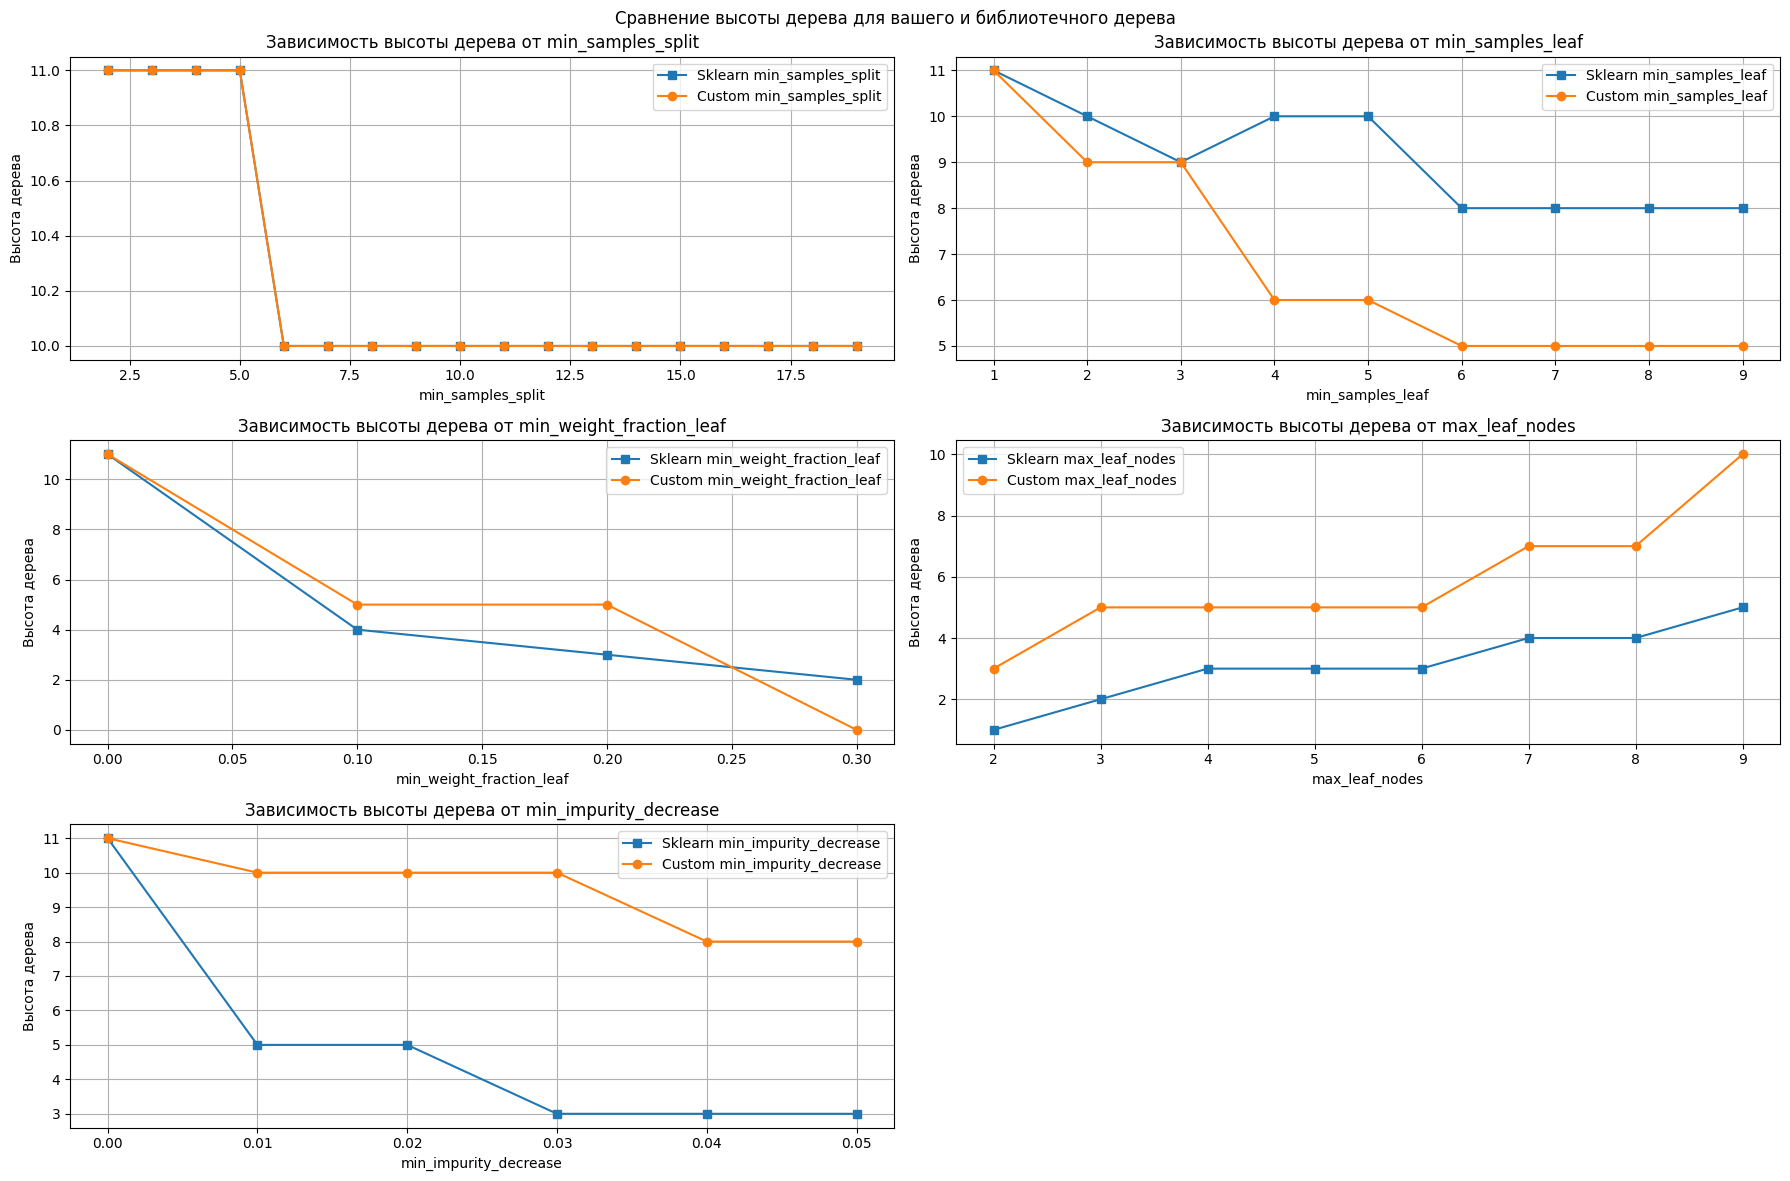

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from TreeClassifier import DecisionTree
from sklearn.tree import DecisionTreeClassifier

param_ranges = {
    'min_samples_split': range(2, 20),
    'min_samples_leaf': range(1, 10),
    'min_weight_fraction_leaf': np.arange(0.0, 0.4, 0.1),
    'max_leaf_nodes': range(2, 10),
    'min_impurity_decrease': np.arange(0.0, 0.06, 0.01)
}

plt.figure(figsize=(18, 12))

for i, (param_name, values) in enumerate(param_ranges.items(), 1):
    custom_tree_heights = []
    sklearn_tree_heights = []

    for value in values:
        tree = DecisionTree(**{param_name: value})
        tree.fit(X_train, y_train)
        custom_tree_heights.append(tree.tree_height)

        sklearn_tree = DecisionTreeClassifier(**{param_name: value})
        sklearn_tree.fit(X_train, y_train)
        sklearn_tree_heights.append(sklearn_tree.get_depth())

    plt.subplot(3, 2, i)
    plt.plot(values, sklearn_tree_heights, marker='s', label=f"Sklearn {param_name}")
    plt.plot(values, custom_tree_heights, marker='o', label=f"Custom {param_name}")

    plt.xlabel(param_name)
    plt.ylabel("Высота дерева")
    plt.title(f"Зависимость высоты дерева от {param_name}")
    plt.grid()
    plt.legend()

plt.suptitle("Сравнение высоты дерева для вашего и библиотечного дерева")
plt.tight_layout()
plt.show()

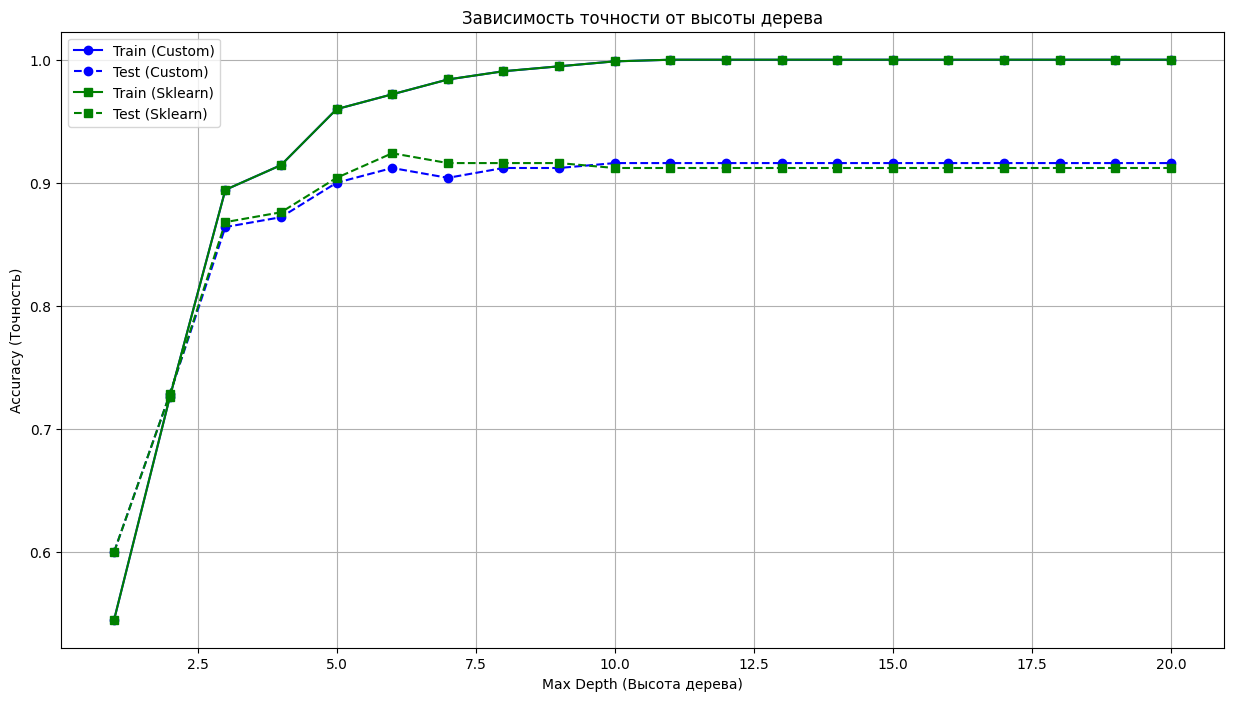

In [7]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from TreeClassifier import DecisionTree

max_depth_values = range(1, 21)

train_accuracy_custom = []
test_accuracy_custom = []
train_accuracy_sklearn = []
test_accuracy_sklearn = []

for max_depth in max_depth_values:
    custom_tree = DecisionTree(max_depth=max_depth)
    custom_tree.fit(X_train, y_train)

    y_train_pred_custom = custom_tree.predict(X_train)
    y_test_pred_custom = custom_tree.predict(X_test)

    train_accuracy_custom.append(accuracy_score(y_train, y_train_pred_custom))
    test_accuracy_custom.append(accuracy_score(y_test, y_test_pred_custom))

    sklearn_tree = DecisionTreeClassifier(max_depth=max_depth)
    sklearn_tree.fit(X_train, y_train)

    y_train_pred_sklearn = sklearn_tree.predict(X_train)
    y_test_pred_sklearn = sklearn_tree.predict(X_test)

    train_accuracy_sklearn.append(accuracy_score(y_train, y_train_pred_sklearn))
    test_accuracy_sklearn.append(accuracy_score(y_test, y_test_pred_sklearn))

plt.figure(figsize=(15, 8))

plt.plot(max_depth_values, train_accuracy_custom, label="Train (Custom)", marker='o', linestyle='-', color='blue')
plt.plot(max_depth_values, test_accuracy_custom, label="Test (Custom)", marker='o', linestyle='--', color='blue')

plt.plot(max_depth_values, train_accuracy_sklearn, label="Train (Sklearn)", marker='s', linestyle='-', color='green')
plt.plot(max_depth_values, test_accuracy_sklearn, label="Test (Sklearn)", marker='s', linestyle='--', color='green')

plt.xlabel("Max Depth (Высота дерева)")
plt.ylabel("Accuracy (Точность)")
plt.title("Зависимость точности от высоты дерева")
plt.legend()
plt.grid()
plt.show()

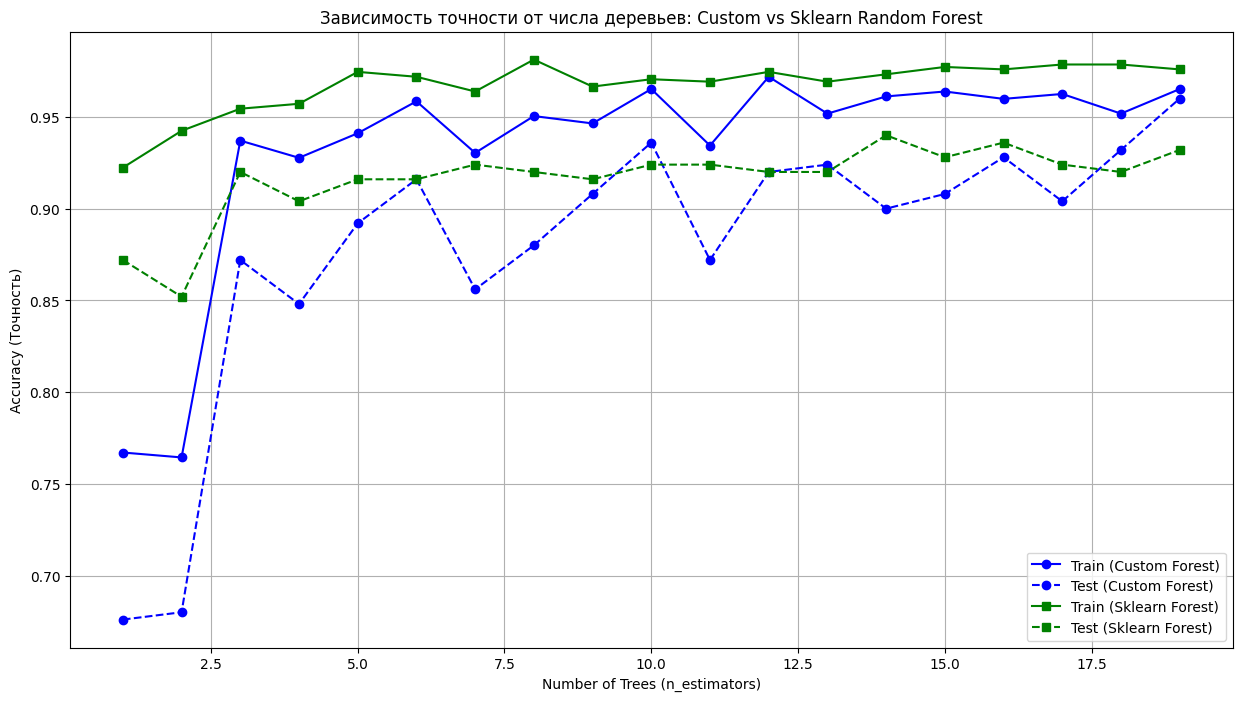

In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from TreeClassifier import RandomForest

n_estimators_values = range(1, 20)

train_accuracy_custom = []
test_accuracy_custom = []
train_accuracy_sklearn = []
test_accuracy_sklearn = []

for n_estimators in n_estimators_values:
    custom_forest = RandomForest(n_estimators=n_estimators, max_depth=6)
    custom_forest.fit(X_train, y_train)

    y_train_pred_custom = custom_forest.predict(X_train)
    y_test_pred_custom = custom_forest.predict(X_test)

    train_accuracy_custom.append(accuracy_score(y_train, y_train_pred_custom))
    test_accuracy_custom.append(accuracy_score(y_test, y_test_pred_custom))
    
    sklearn_forest = RandomForestClassifier(n_estimators=n_estimators, max_depth=6)
    sklearn_forest.fit(X_train, y_train)

    y_train_pred_sklearn = sklearn_forest.predict(X_train)
    y_test_pred_sklearn = sklearn_forest.predict(X_test)

    train_accuracy_sklearn.append(accuracy_score(y_train, y_train_pred_sklearn))
    test_accuracy_sklearn.append(accuracy_score(y_test, y_test_pred_sklearn))

plt.figure(figsize=(15, 8))

plt.plot(n_estimators_values, train_accuracy_custom, label="Train (Custom Forest)", marker='o', linestyle='-', color='blue')
plt.plot(n_estimators_values, test_accuracy_custom, label="Test (Custom Forest)", marker='o', linestyle='--', color='blue')

plt.plot(n_estimators_values, train_accuracy_sklearn, label="Train (Sklearn Forest)", marker='s', linestyle='-', color='green')
plt.plot(n_estimators_values, test_accuracy_sklearn, label="Test (Sklearn Forest)", marker='s', linestyle='--', color='green')

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy (Точность)")
plt.title("Зависимость точности от числа деревьев: Custom vs Sklearn Random Forest")
plt.legend()
plt.grid()
plt.show()

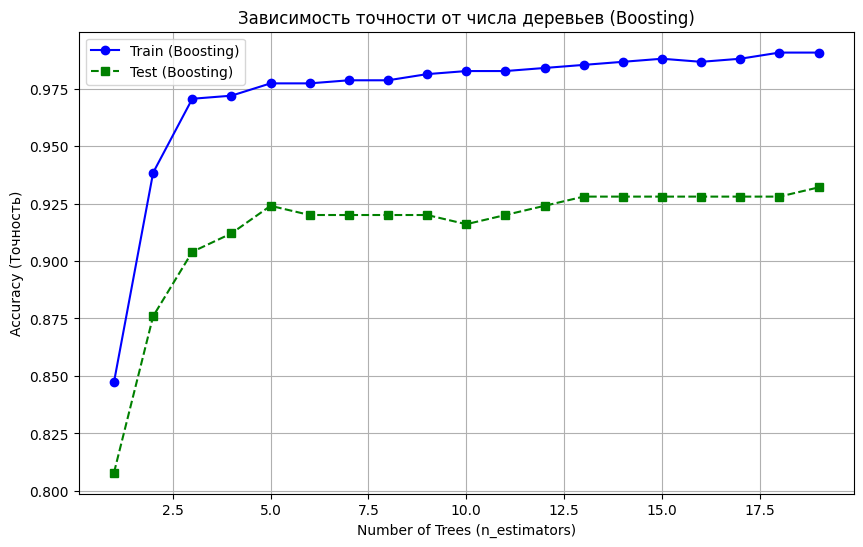

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.ensemble import GradientBoostingClassifier

n_estimators_values = range(1, 20)

train_accuracy_boosting = []
test_accuracy_boosting = []

for n_estimators in n_estimators_values:
    boosting_model = GradientBoostingClassifier(n_estimators=n_estimators, max_depth=3, random_state=42)
    boosting_model.fit(X_train, y_train)
    
    y_train_pred_boosting = boosting_model.predict(X_train)
    y_test_pred_boosting = boosting_model.predict(X_test)

    train_accuracy_boosting.append(accuracy_score(y_train, y_train_pred_boosting))
    test_accuracy_boosting.append(accuracy_score(y_test, y_test_pred_boosting))

plt.figure(figsize=(10, 6))

plt.plot(n_estimators_values, train_accuracy_boosting, marker='o', linestyle='-', color='blue', label="Train (Boosting)")
plt.plot(n_estimators_values, test_accuracy_boosting, marker='s', linestyle='--', color='green', label="Test (Boosting)")

plt.xlabel("Number of Trees (n_estimators)")
plt.ylabel("Accuracy (Точность)")
plt.title("Зависимость точности от числа деревьев (Boosting)")
plt.legend()
plt.grid()
plt.show()